<a href="https://colab.research.google.com/github/Vidhya-95/deep_learning/blob/main/Deep_Learning_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
#Importing libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Understanding the cifar10 dataset:
The 10 represents 10 different classes labelled 0 to 9. There are 50000 training dataset and 10000 testing dataset.

In [32]:
#Loading dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [33]:
print("Shape of training dataset : ",X_train.shape)
print("Shape of testing dataset : ",X_test.shape)

Shape of training dataset :  (50000, 32, 32, 3)
Shape of testing dataset :  (10000, 32, 32, 3)


# Data Preprocessing

## Resizing and Normalization:
- We are **resizing** images to have 224*224 pixels (with 3 channels RGB) for uniformity in image size.
- **Normalizing** the pixel values converts each pixel value between 0 and 1. This helps us to train our model and converge faster as values are smaller.

In [34]:
img_size = 224
resize_and_rescale = keras.Sequential([
  layers.Resizing(img_size, img_size),
  layers.Rescaling(1./255)
])

## Data Augmentation
We will be using keras image preprocessing layers to perform augmentation. This will enable to train our model on a large amount of data and create a generalized model and prevent overfitting.

In [35]:
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.2)
])

# Model Training

In [36]:
model = keras.Sequential([
    #Adding preprocessing layers
    resize_and_rescale,
    data_augmentation,
    #Adding convolution layers along with maxpooling
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    #Flattening the output from maxpooling for forming dense neural network
    layers.Flatten(),
    layers.Dense(128, activation='relu'), #128 here is the output units
    #Ouput layer with 10 classes
    layers.Dense(10)
])

In [37]:
#Compiling the model
model.compile(optimizer='adam',loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])


In [38]:
## Print model summary
print("CNN Model Summary")
model.summary()


CNN Model Summary


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=5,
    restore_best_weights=True
)

In [40]:
#Fitting our training dataset
model_history = model.fit(
  X_train, y_train,
  epochs=50,
  batch_size=200,
  validation_split=0.2,
  callbacks=[early_stopping]
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 37s 161ms/step - accuracy: 0.3210 - loss: 1.8653 - val_accuracy: 0.4026 - val_loss: 1.6505
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 32s 158ms/step - accuracy: 0.4170 - loss: 1.6225 - val_accuracy: 0.4465 - val_loss: 1.5499
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 156ms/step - accuracy: 0.4465 - loss: 1.5516 - val_accuracy: 0.4637 - val_loss: 1.5173
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 32s 158ms/step - accuracy: 0.4620 - loss: 1.5053 - val_accuracy: 0.4923 - val_loss: 1.4374
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 157ms/step - accuracy: 0.4747 - loss: 1.4700 - val_accuracy: 0.4901 - val_loss: 1.4378
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 157ms/step - accuracy: 0.4805 - loss: 1.4472 - val_accuracy: 0.5032 - val_loss: 1.3970
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 157ms/step - accuracy: 0.4958 - loss: 1.4169 - val_accuracy: 0.5124 - val_loss: 1.3983
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 157ms/step - accuracy: 0.4997 - loss: 1

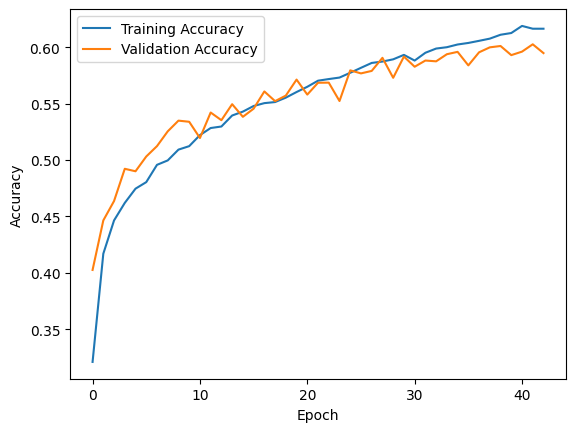

In [41]:
#Let's plot some graphs to visualize our accuracy in training and validation as well as our loss for both
plt.plot(model_history.history['accuracy'],label = 'Training Accuracy')
plt.plot(model_history.history['val_accuracy'],label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

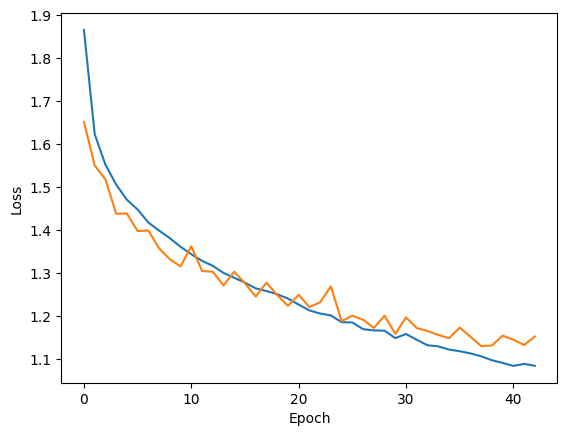

In [42]:
plt.plot(model_history.history['loss'],label = 'Training loss')
plt.plot(model_history.history['val_loss'],label = 'Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [43]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (200, 224, 224, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (200, 224, 224, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (200, 224, 224, 16)    │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (200, 112, 112, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (200, 112, 112, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (200, 56, 56, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (200, 56, 56, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (200, 28, 28, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (200, 50176)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (200, 128)             │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (200, 10)              │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,342,592 (73.79 MB)

 Trainable params: 6,447,530 (24.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,895,062 (49.19 MB)

# Model Evaluation

In [44]:
test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)
print("Test Loss : {:.2f}" .format(test_loss))
print("Test Accuracy : {:.2f}" .format(test_acc))

313/313 - 2s - 7ms/step - accuracy: 0.6054 - loss: 1.1156
Test Loss : 1.12
Test Accuracy : 0.61


# Implementing cnn model using Transfer Learning
We can use pre-trained models such as VGG16, ResNet50, or MobileNetV2 as our base model and fit our training data to achieve a higher accuracy as these base models are trained on a huge amount of data and its weights are optimized.Rather than building our own complex model we use pre-trained models to effectively train on our own dataset and improve accuracy.

In [45]:
#Importing libraries for our pre-trained model
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

In [46]:
#Configuring our base model as InceptionV3 and removing fully connected layers by setting include_top=False
base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

In [47]:
list(base_model.layers)

[<InputLayer name=input_layer_9, built=True>,
 <Conv2D name=conv2d_100, built=True>,
 <BatchNormalization name=batch_normalization_94, built=True>,
 <Activation name=activation_94, built=True>,
 <Conv2D name=conv2d_101, built=True>,
 <BatchNormalization name=batch_normalization_95, built=True>,
 <Activation name=activation_95, built=True>,
 <Conv2D name=conv2d_102, built=True>,
 <BatchNormalization name=batch_normalization_96, built=True>,
 <Activation name=activation_96, built=True>,
 <MaxPooling2D name=max_pooling2d_10, built=True>,
 <Conv2D name=conv2d_103, built=True>,
 <BatchNormalization name=batch_normalization_97, built=True>,
 <Activation name=activation_97, built=True>,
 <Conv2D name=conv2d_104, built=True>,
 <BatchNormalization name=batch_normalization_98, built=True>,
 <Activation name=activation_98, built=True>,
 <MaxPooling2D name=max_pooling2d_11, built=True>,
 <Conv2D name=conv2d_108, built=True>,
 <BatchNormalization name=batch_normalization_102, built=True>,
 <Activat

In [48]:
# Freeze all layers
for layer in base_model.layers:
  layer.trainable = False

In [49]:
# Building model with base model
cnn_inceptionv3 = keras.Sequential([
    resize_and_rescale,
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10,activation='softmax')
])

In [50]:
# Compiling model
cnn_inceptionv3.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
cnn_inceptionv3_model_history = cnn_inceptionv3.fit(
  X_train, y_train,
  epochs=50,
  batch_size=200,
  validation_split=0.2,
  callbacks=[early_stopping]
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 127s 570ms/step - accuracy: 0.5527 - loss: 1.2720 - val_accuracy: 0.7545 - val_loss: 0.7357
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 110s 550ms/step - accuracy: 0.6324 - loss: 1.0494 - val_accuracy: 0.7661 - val_loss: 0.6926
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 110s 549ms/step - accuracy: 0.6480 - loss: 1.0014 - val_accuracy: 0.7796 - val_loss: 0.6675
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 110s 548ms/step - accuracy: 0.6553 - loss: 0.9851 - val_accuracy: 0.7550 - val_loss: 0.7121
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 110s 549ms/step - accuracy: 0.6620 - loss: 0.9599 - val_accuracy: 0.7855 - val_loss: 0.6264
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 110s 549ms/step - accuracy: 0.6695 - loss: 0.9400 - val_accuracy: 0.7866 - val_loss: 0.6183
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 110s 549ms/step - accuracy: 0.6718 - loss: 0.9353 - val_accuracy: 0.7934 - val_loss: 0.6082
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 110s 549ms/step - accuracy: 0.6769 -

In [ ]:
test_loss,test_acc= cnn_inceptionv3.evaluate(X_test,  y_test, verbose=2)
print("Test Loss : {:.2f}" .format(test_loss))
print("Test Accuracy : {:.2f}" .format(test_acc))